# Objectif du notebook 

Date de création : 29/04/2026

Illustration propre du pipeline de traitements appliqués pour le calcul des RTFs. 

La procédure est illustré sur la séquence 116 (séquence statique). 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "illustration_processing")

In [3]:
sensibility_img_folder

'c:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\real_data_analysis\\fiberscope_groix\\img\\rtf_mfp\\illustration_processing'

In [4]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [5]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [6]:
seq_id = 116
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [7]:
print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")


Signal properties for sequence 116:
	Number of pulses: 10
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 10.0 seconds


# Étape 2 : choix des paramètres de l'estimateur CS-EVD 

Le succès de la méthode proposée repose en grande partie sur la capacité à estimer correctement la grandeur signante d'intérêt, à savoir le vecteur de RTFs. 

Dans le cas de signaux actifs, le vecteur de RTFs peut également être estimé par déconvolution du signal reçu. Pour chaque émission considérée, le vecteur de RTF estimée par déconvolution est utilisé comme référence et comparé au vecteur de RTF estimé par la méthode CS-EVD et ce, pour différents paramètres de l'estimateur CS-EVD. 

In [8]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study below 
    "tau_rtf_analysis": 3.0,
    "alpha_overlap": 0.9,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=True,
    verbose=True,
)

In [9]:
print(rtf_mfp_processor.fsm_nperseg, rtf_mfp_processor.fsm_noverlap)
# fsm_active nperseg and noverlap are only updated when we run the processor
print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)
print(2**13)

8192 7372
4096 2048
8192


In [10]:
###########################
# Dummy
###########################
id_library = 100

active_replicas_args = {
    "replica_sequence_ids": [seq_id],
    "replica_pulse_slice": [],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# id_library = 11
# active_replicas_args = {
#     "replica_sequence_ids": [],
#     "replica_pulse_slice": [],
#     "load_precomputed_feature": False,
# }
# passive_replicas_args = {
#     "start_datetimes": [
#         datetime(year=2025, month=10, day=15, hour=10, minute=14, second=00),  # OK
#     ],
#     "end_datetimes": [
#         datetime(year=2025, month=10, day=15, hour=10, minute=18, second=00),  # OK
#     ],
#     "load_precomputed_feature": False,
# }

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
)


Deriving features for active source...

Provided pulse slices dont match number of pulses in sequence, no slice applied.

RTF processing of sequences [116] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 116
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Deriving replicas for passive source...
A library dataset with ID 100 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_100.nc.


In [11]:
print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)
print(2**13)

8192 7372
8192


In [12]:
# Select frequency range
fmin = 400
fmax = 800

In [13]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_100.nc"
ds = xr.open_dataset(fpath)
ds

<xarray.Dataset> Size: 2MB
Dimensions:           (h_index: 3, f_rtf: 4097, replica_id: 10, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int32 12B 1 2 3
  * f_rtf             (f_rtf) float32 16kB 0.0 0.2441 0.4883 ... 999.8 1e+03
  * replica_id        (replica_id) int32 40B 0 1 2 3 4 5 6 7 8 9
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 492kB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 492kB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 648kB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 648kB ...
    feature_psd       (f_rtf, replica_id) float32 164kB ...
    e_replica         (replica_id) float32 40B ...
    n_replica         (replica_id) float32 40B ...
    u_replica         (replica_id) float32 40B ...
    replica_type      (replica_id) int32 40B ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     100

In [14]:
fig_folder = os.path.join(sensibility_img_folder, f"seq_{seq_id}_library_{ds.id}")
os.makedirs(fig_folder, exist_ok=True)

In [15]:
fpath = os.path.join(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active", f"sequence_{seq_id}_rtf.nc")
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 11MB
Dimensions:                     (h_index: 3, time: 211259, pulse_id: 10,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 4097,
                                 f_csdm: 4097, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int32 12B 1 2 3
  * time                        (time) float32 845kB 0.0 0.0005 ... 105.6 105.6
  * pulse_id                    (pulse_id) int64 80B 0 1 2 3 4 5 6 7 8 9
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 16kB 0.0 0.2441 ... 999.8 1e+03
  * f_csdm                      (f_csdm) float32 16kB 0.0 0.2441 ... 999.8 1e+03
  * h_index_bis                 (h_index_bis) int32 12B 1 2 3
Data variables:
    signal                      (h_index, time) float32 3MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 120B ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 1MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 648kB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 648kB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 492kB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 492kB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 1MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 1MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 648kB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 648kB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        5.619
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_07-08-07
    ...                        ...
    inter_pulse_period:        10.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     13.64

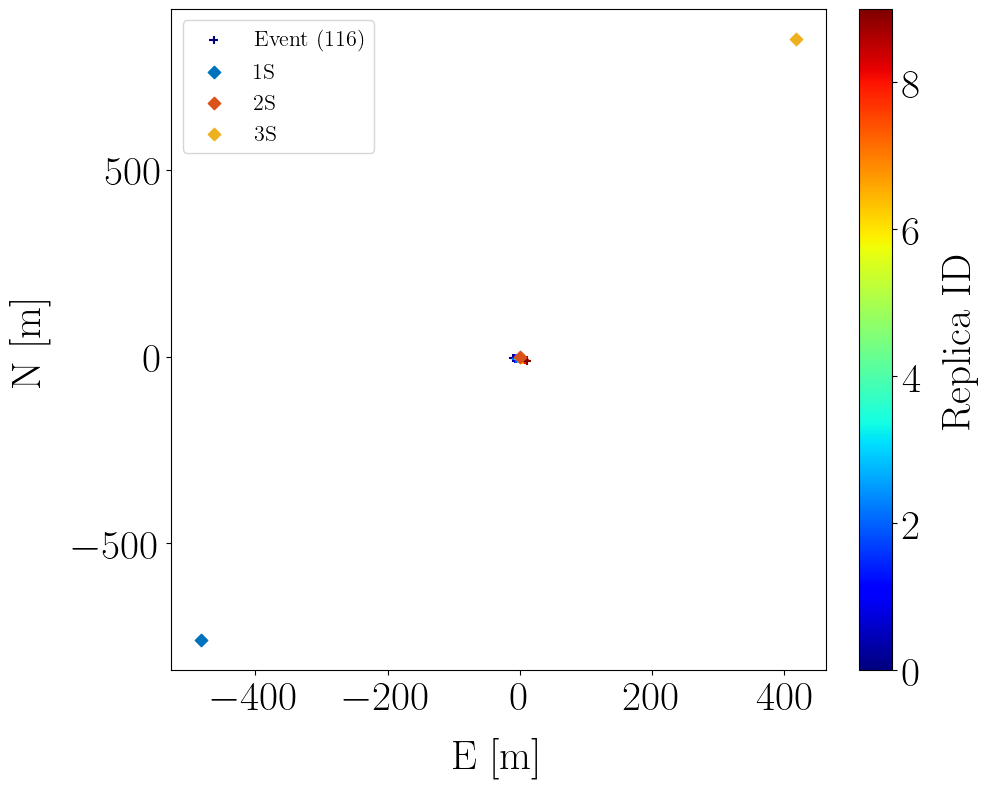

In [16]:
root_img_traj = os.path.join(fig_folder, "trajectory")
os.makedirs(root_img_traj, exist_ok=True)
plot_seq_replica_positions(df_seq, ds_gps, root_fig=root_img_traj)

Median source speed along traj : vs = 0.24 m.s-1
Std source speed along traj : vs = 0.00 m.s-1


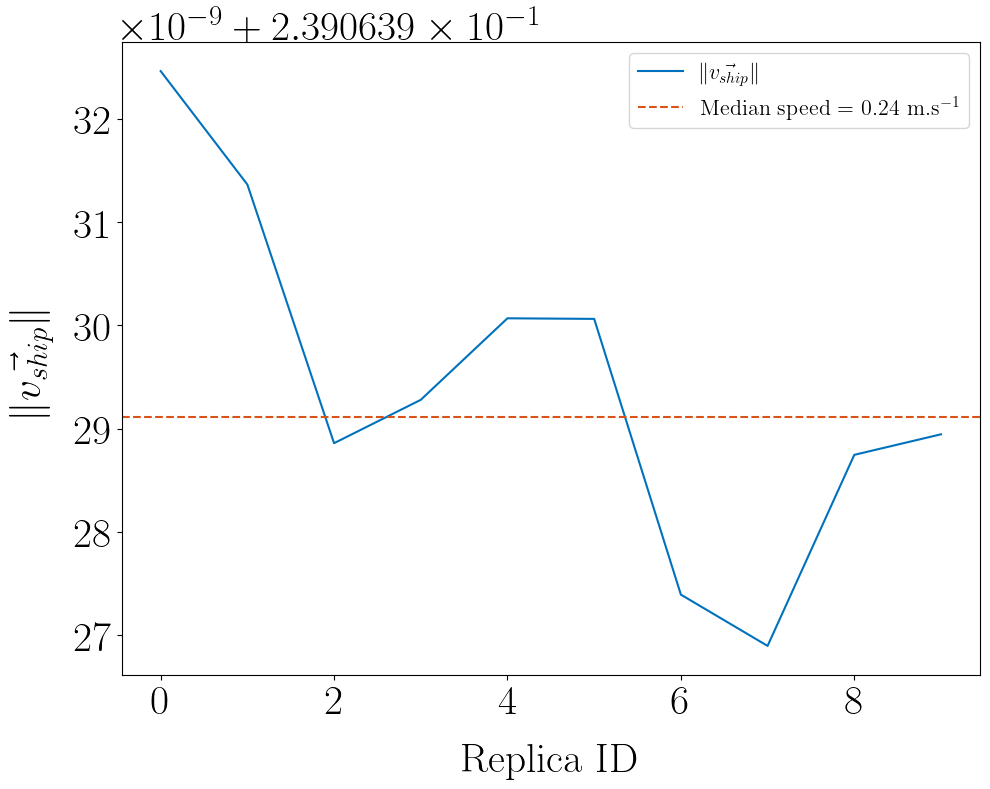

In [17]:
plot_speed_along_seq(df_seq, root_fig=root_img_traj)

La source est statique. 

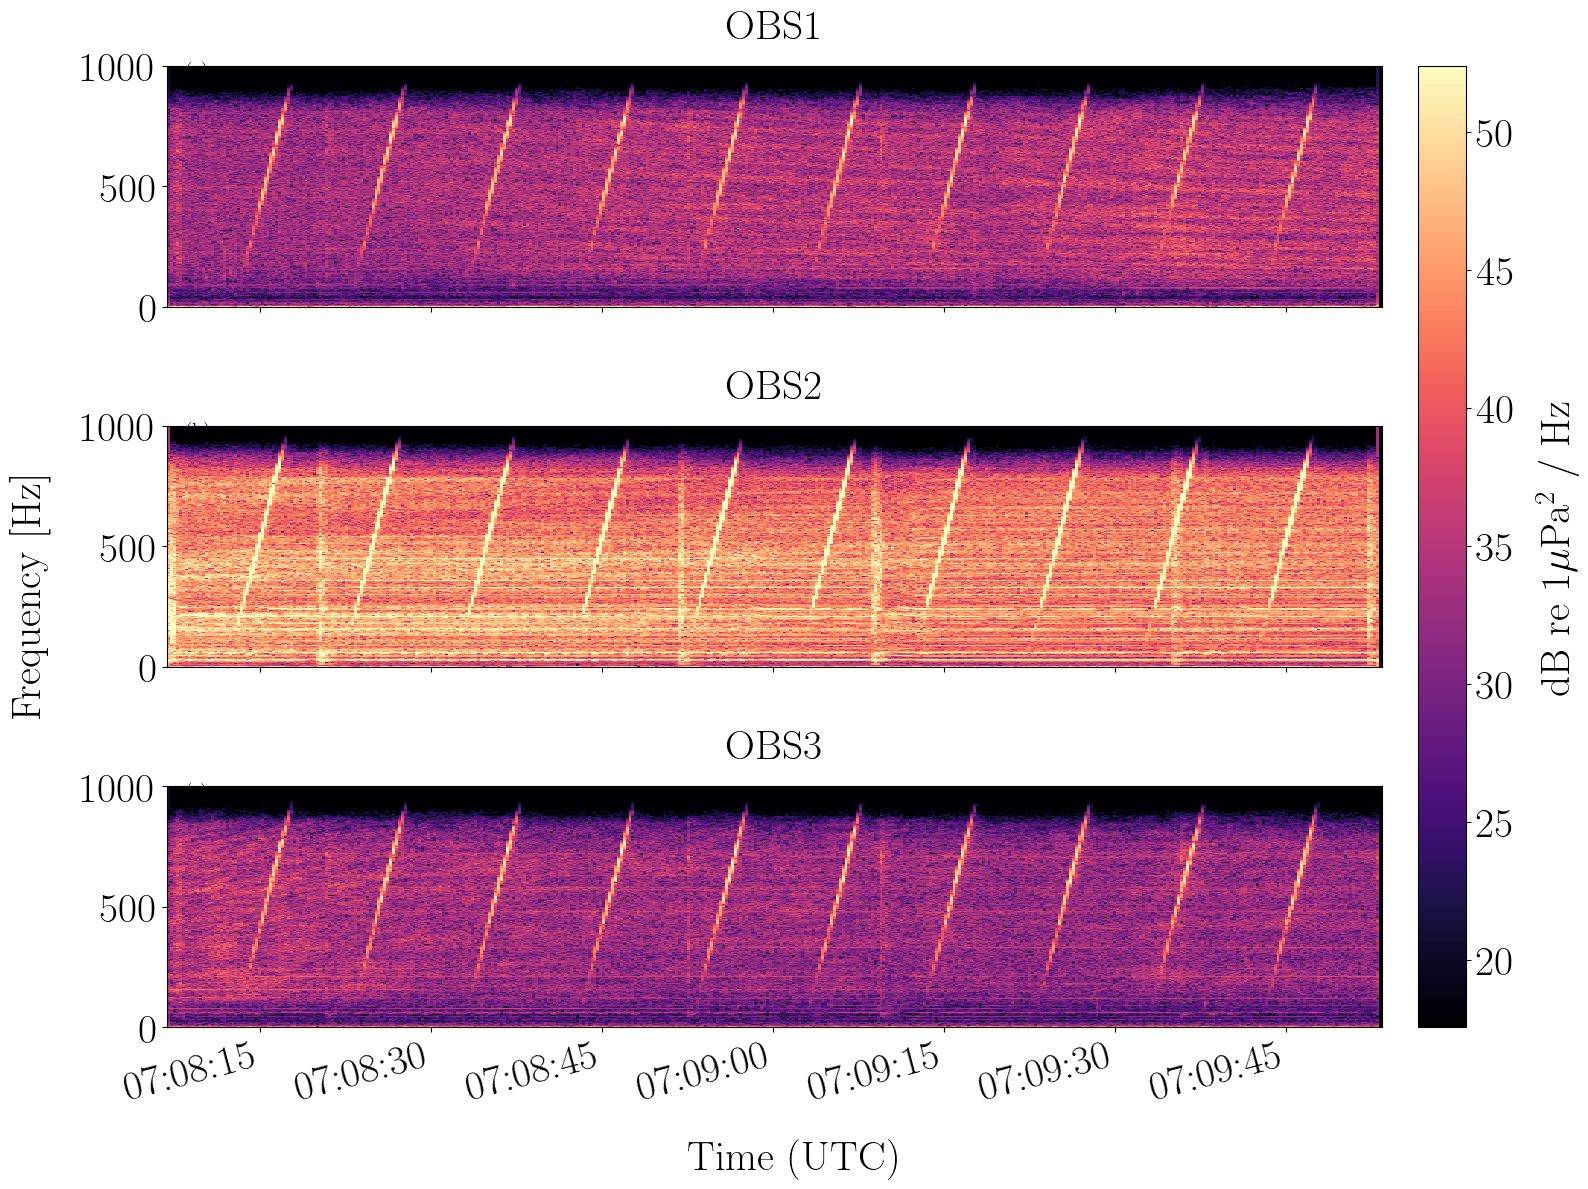

In [18]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

plot_sequence_spectrogram(
    ds_sig,
    ds_wav,
    fig_folder=fig_folder,
    nperseg=2**10,
    noverlap=2**9,
    fmin=0,
    fmax=1000,
    fname="sequence_signal_spectrogram.png",
)